# OSV-5M StreetCLIP Training for Colab

This notebook fine-tunes `geolocal/StreetCLIP` on a small OSV-5M subset without using the Hugging Face `datasets` loader.

It does four things:
1. downloads `train.csv` plus one selected train zip shard from `osv5m/osv5m`,
2. builds up to 10,000 image-text pairs,
3. fine-tunes two StreetCLIP variants:
   - `clean`: no JPEG augmentation
   - `jpeg_aug`: randomized JPEG compression during training
4. saves checkpoints and final weights to a user-defined Google Drive path.

The text target is a location label built from metadata, by default `city, region, country`.


In [1]:
%%capture
!pip -q install --upgrade --no-cache-dir "transformers>=4.41,<5" "huggingface_hub>=0.34" pandas pillow numpy tqdm matplotlib


In [1]:
from __future__ import annotations

import io
import json
import math
import random
import time
import zipfile
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from huggingface_hub import HfApi, hf_hub_download
from PIL import Image, UnidentifiedImageError
from torch import nn
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from transformers import CLIPModel, CLIPProcessor, get_cosine_schedule_with_warmup

SEED = 13
TARGET_SAMPLES = 10000
VAL_RATIO = 0.1
BATCH_SIZE = 16
NUM_EPOCHS = 5
LEARNING_RATE = 1e-5
WEIGHT_DECAY = 0.01
MAX_GRAD_NORM = 1.0
NUM_WORKERS = 2
LABEL_LEVEL = "city_region_country"
REPO_ID = "osv5m/osv5m"
REPO_TYPE = "dataset"
TRAIN_SHARD_INDEX = 0
FORCE_REDOWNLOAD = False
SKIP_EXISTING_DOWNLOADS = True
USE_GOOGLE_DRIVE = True
GOOGLE_DRIVE_ROOT = "/content/drive/MyDrive/SP26Courses/cse5509"
OUTPUT_SUBDIR = "osv5m_10k_runs"
JPEG_AUG_MIN_QUALITY = 30
JPEG_AUG_MAX_QUALITY = 90

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if USE_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    ROOT_DIR = Path(GOOGLE_DRIVE_ROOT)
else:
    ROOT_DIR = Path("/content/streetclip_training")

DATA_DIR = ROOT_DIR / "data_cache"
RAW_DIR = DATA_DIR / "raw"
EXTRACT_DIR = DATA_DIR / "extracted"
IMAGES_DIR = DATA_DIR / "images"
RUNS_DIR = ROOT_DIR / OUTPUT_SUBDIR
SAMPLED_METADATA_CSV = DATA_DIR / "sampled_train_metadata.csv"
DOWNLOAD_MANIFEST_JSON = DATA_DIR / "download_manifest.json"

for path in [RAW_DIR, EXTRACT_DIR, IMAGES_DIR, RUNS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print({
    "device": str(DEVICE),
    "target_samples": TARGET_SAMPLES,
    "batch_size": BATCH_SIZE,
    "epochs": NUM_EPOCHS,
    "output_dir": str(RUNS_DIR),
})


Mounted at /content/drive
{'device': 'cuda', 'target_samples': 10000, 'batch_size': 16, 'epochs': 5, 'output_dir': '/content/drive/MyDrive/SP26Courses/cse5509/osv5m_10k_runs'}


In [2]:
def clean_text(value: object) -> str:
    if value is None:
        return ""
    text = str(value).strip()
    return "" if text.lower() == "nan" else text


def build_label(row: pd.Series, level: str = LABEL_LEVEL) -> str:
    city = clean_text(row.get("city"))
    region = clean_text(row.get("region"))
    country = clean_text(row.get("country"))

    if level == "country":
        return country or "Unknown country"
    if level == "region_country":
        parts = [part for part in [region, country] if part]
        return ", ".join(parts) or "Unknown region"

    parts = [part for part in [city, region, country] if part]
    return ", ".join(parts) or "Unknown city"


def list_repo_files() -> list[str]:
    api = HfApi()
    return api.list_repo_files(repo_id=REPO_ID, repo_type=REPO_TYPE)


def choose_repo_file(files: list[str], split_name: str, suffix: str, shard_index: int | None = None) -> str:
    candidates = [path for path in files if split_name in path.lower() and path.lower().endswith(suffix)]
    if not candidates:
        raise FileNotFoundError(f"Could not find {split_name} {suffix} in the OSV-5M repo.")
    if shard_index is None:
        return sorted(candidates)[0]

    exact_suffixes = [f"/{shard_index:02d}{suffix}", f"_{shard_index:02d}{suffix}", f"-{shard_index:02d}{suffix}"]
    exact = [path for path in candidates if any(path.endswith(token) for token in exact_suffixes)]
    if exact:
        return sorted(exact)[0]

    sorted_candidates = sorted(candidates)
    if shard_index >= len(sorted_candidates):
        raise IndexError(f"Requested shard {shard_index}, but only found {len(sorted_candidates)} files.")
    return sorted_candidates[shard_index]


def extract_zip_once(zip_path: Path, output_dir: Path) -> None:
    marker = output_dir / ".done"
    if marker.exists():
        return
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(output_dir)
    marker.write_text("ok")


def build_image_indexes(root: Path) -> tuple[dict[str, Path], dict[str, Path]]:
    by_name = {}
    by_stem = {}
    for path in root.rglob("*"):
        if path.suffix.lower() not in {".jpg", ".jpeg", ".png", ".webp"}:
            continue
        by_name[path.name] = path
        by_stem[path.stem] = path
    return by_name, by_stem


def resolve_local_image(row: pd.Series, by_name: dict[str, Path], by_stem: dict[str, Path]) -> Path | None:
    candidate_columns = ["image", "image_path", "filename", "file_name", "id", "image_id", "key", "panoid"]
    for column in candidate_columns:
        if column not in row.index:
            continue
        raw_value = clean_text(row[column])
        if not raw_value:
            continue
        pathish = Path(raw_value)
        if pathish.name in by_name:
            return by_name[pathish.name]
        if pathish.stem in by_stem:
            return by_stem[pathish.stem]
        for ext in [".jpg", ".jpeg", ".png", ".webp"]:
            probe = f"{raw_value}{ext}"
            if probe in by_name:
                return by_name[probe]
    return None


def randomized_jpeg(image: Image.Image, min_quality: int, max_quality: int) -> Image.Image:
    quality = random.randint(min_quality, max_quality)
    buffer = io.BytesIO()
    image.save(buffer, format="JPEG", quality=quality)
    buffer.seek(0)
    return Image.open(buffer).convert("RGB")


def maybe_download(repo_filename: str, local_root: Path, force_redownload: bool = False) -> Path:
    local_path = local_root / repo_filename
    local_path.parent.mkdir(parents=True, exist_ok=True)
    if local_path.exists() and not force_redownload:
        return local_path
    downloaded = hf_hub_download(
        repo_id=REPO_ID,
        repo_type=REPO_TYPE,
        filename=repo_filename,
        local_dir=local_root,
        local_dir_use_symlinks=False,
    )
    return Path(downloaded)


def infer_existing_train_csv(search_root: Path) -> Path:
    csv_candidates = sorted(path for path in search_root.rglob('*.csv') if 'train' in str(path).lower())
    if not csv_candidates:
        raise FileNotFoundError(f'No train CSV found under {search_root}.')
    return csv_candidates[0]


def infer_existing_train_zip(raw_dir: Path, shard_index: int) -> Path | None:
    zip_candidates = sorted(path for path in raw_dir.rglob('*.zip') if 'train' in str(path).lower())
    if not zip_candidates:
        return None

    exact_suffixes = [f'/{shard_index:02d}.zip', f'_{shard_index:02d}.zip', f'-{shard_index:02d}.zip']
    exact = [path for path in zip_candidates if any(str(path).endswith(token) for token in exact_suffixes)]
    return exact[0] if exact else zip_candidates[min(shard_index, len(zip_candidates) - 1)]


def infer_extracted_image_root(extract_dir: Path, shard_index: int) -> Path:
    preferred = [
        extract_dir / f'{shard_index:02d}' / f'{shard_index:02d}',
        extract_dir / f'{shard_index:02d}',
    ]
    for path in preferred:
        if path.exists() and any(p.suffix.lower() in {'.jpg', '.jpeg', '.png', '.webp'} for p in path.rglob('*')):
            return path

    nested_dirs = sorted(path for path in extract_dir.rglob('*') if path.is_dir())
    for path in nested_dirs:
        if any(p.suffix.lower() in {'.jpg', '.jpeg', '.png', '.webp'} for p in path.rglob('*')):
            return path

    raise FileNotFoundError(f'No extracted image directory with images found under {extract_dir}.')


def save_model_artifacts(model: CLIPModel, processor: CLIPProcessor, output_dir: Path) -> None:
    output_dir.mkdir(parents=True, exist_ok=True)
    model.save_pretrained(output_dir)
    processor.save_pretrained(output_dir)


@dataclass
class TrainConfig:
    run_name: str
    jpeg_aug: bool


## 1. Download and preprocess in separate cells

Cell A downloads `train.csv` and one train shard only.
Cell B does metadata matching and sampled-subset preparation only. It trains directly from the extracted cache and does not copy images.

If the download and extracted images are already in Drive, skip Cell A and run Cell B directly.


In [3]:
# repo_files = list_repo_files()
# train_csv_repo_path = choose_repo_file(repo_files, "train", ".csv")
# train_zip_repo_path = choose_repo_file(repo_files, "train", ".zip", shard_index=TRAIN_SHARD_INDEX)

# print("train.csv:", train_csv_repo_path)
# print("train shard:", train_zip_repo_path)

# if SKIP_EXISTING_DOWNLOADS and (RAW_DIR / train_csv_repo_path).exists() and (RAW_DIR / train_zip_repo_path).exists():
#     local_train_csv = RAW_DIR / train_csv_repo_path
#     local_train_zip = RAW_DIR / train_zip_repo_path
#     print("Reusing existing download files.")
# else:
#     local_train_csv = maybe_download(train_csv_repo_path, RAW_DIR, force_redownload=FORCE_REDOWNLOAD)
#     local_train_zip = maybe_download(train_zip_repo_path, RAW_DIR, force_redownload=FORCE_REDOWNLOAD)

# manifest = {
#     "train_csv_repo_path": train_csv_repo_path,
#     "train_zip_repo_path": train_zip_repo_path,
#     "local_train_csv": str(local_train_csv),
#     "local_train_zip": str(local_train_zip),
# }
# DOWNLOAD_MANIFEST_JSON.write_text(json.dumps(manifest, indent=2))

# print("local csv:", local_train_csv)
# print("local zip:", local_train_zip)
# print("manifest:", DOWNLOAD_MANIFEST_JSON)


In [4]:
if SAMPLED_METADATA_CSV.exists():
    print("Reusing existing sampled metadata:", SAMPLED_METADATA_CSV)
    metadata_df = pd.read_csv(SAMPLED_METADATA_CSV)
else:
    if DOWNLOAD_MANIFEST_JSON.exists():
        manifest = json.loads(DOWNLOAD_MANIFEST_JSON.read_text())
        local_train_csv = Path(manifest["local_train_csv"])
        local_train_zip = Path(manifest["local_train_zip"]) if manifest.get("local_train_zip") else None
        extract_target = Path(manifest["extract_target"]) if manifest.get("extract_target") else None
        print("Using download manifest:", DOWNLOAD_MANIFEST_JSON)
    else:
        local_train_csv = infer_existing_train_csv(DATA_DIR)
        local_train_zip = infer_existing_train_zip(RAW_DIR, TRAIN_SHARD_INDEX)
        extract_target = infer_extracted_image_root(EXTRACT_DIR, TRAIN_SHARD_INDEX)
        manifest = {
            "local_train_csv": str(local_train_csv),
            "local_train_zip": str(local_train_zip) if local_train_zip is not None else "",
            "extract_target": str(extract_target),
        }
        DOWNLOAD_MANIFEST_JSON.write_text(json.dumps(manifest, indent=2))
        print("Inferred existing files from Drive cache.")
        print("local csv:", local_train_csv)
        print("local zip:", local_train_zip)
        print("extract target:", extract_target)

    if extract_target is None:
        if local_train_zip is None:
            extract_target = infer_extracted_image_root(EXTRACT_DIR, TRAIN_SHARD_INDEX)
        else:
            extract_target = EXTRACT_DIR / local_train_zip.stem
            extract_target.mkdir(parents=True, exist_ok=True)
            extract_zip_once(local_train_zip, extract_target)

    metadata_df = pd.read_csv(local_train_csv)
    metadata_df.columns = [str(column).strip() for column in metadata_df.columns]
    by_name, by_stem = build_image_indexes(extract_target)
    print("Using extracted image root:", extract_target)

    resolved_paths = []
    for _, row in tqdm(metadata_df.iterrows(), total=len(metadata_df), desc="Matching metadata to images"):
        resolved = resolve_local_image(row, by_name, by_stem)
        resolved_paths.append(str(resolved) if resolved is not None else "")

    metadata_df["resolved_image_path"] = resolved_paths
    metadata_df = metadata_df[metadata_df["resolved_image_path"] != ""].copy()

    rename_map = {}
    for source, target in {"sub-region": "sub_region", "sub_region": "sub_region"}.items():
        if source in metadata_df.columns:
            rename_map[source] = target
    metadata_df = metadata_df.rename(columns=rename_map)

    for column in ["country", "region", "sub_region", "city"]:
        if column not in metadata_df.columns:
            metadata_df[column] = ""

    metadata_df["text_label"] = metadata_df.apply(build_label, axis=1)
    metadata_df = metadata_df[metadata_df["text_label"].str.len() > 0].copy()
    metadata_df = metadata_df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
    metadata_df = metadata_df.head(min(TARGET_SAMPLES, len(metadata_df))).copy()
    metadata_df["sample_id"] = np.arange(len(metadata_df))
    metadata_df["image_path"] = metadata_df["resolved_image_path"]
    metadata_df.to_csv(SAMPLED_METADATA_CSV, index=False)

metadata_df = pd.read_csv(SAMPLED_METADATA_CSV)
metadata_df.head()


Reusing existing sampled metadata: /content/drive/MyDrive/SP26Courses/cse5509/data_cache/sampled_train_metadata.csv


,id,latitude,longitude,thumb_original_url,country,sequence,captured_at,lon_bin,lat_bin,cell,...,unique_region,unique_sub-region,unique_city,unique_country,creator_username,creator_id,resolved_image_path,text_label,sample_id,image_path
0,372646764052463,43.263076,142.031001,https://scontent-cdg4-3.xx.fbcdn.net/m1/v/t6/A...,JP,w3h41BwPxpqAaqW4O-1NoQ,1447928366564,88,72,"(88, 72)",...,Hokkaido_JP,NaN,Bibai_NaN_Hokkaido_JP,JP,golgolkara,1.016600e+14,/content/drive/MyDrive/SP26Courses/cse5509/dat...,"Bibai, Hokkaido, JP",0,/content/drive/MyDrive/SP26Courses/cse5509/dat...
1,1133220520521502,-36.770769,174.547917,https://scontent-cdg4-1.xx.fbcdn.net/m1/v/t6/A...,NZ,v4heevhv98qgtn8daw8jyd,1615029810500,97,13,"(97, 13)",...,Auckland_NZ,Auckland_Auckland_NZ,Muriwai Beach_Auckland_Auckland_NZ,NZ,ralley,1.074649e+14,/content/drive/MyDrive/SP26Courses/cse5509/dat...,"Muriwai Beach, Auckland, NZ",1,/content/drive/MyDrive/SP26Courses/cse5509/dat...
2,758792264838391,58.891742,26.285389,https://scontent-cdg4-3.xx.fbcdn.net/m1/v/t6/A...,EE,9MYKii9ZQeVPeH6WYublcg,1466693180798,56,84,"(56, 84)",...,Laeaene-Virumaa_EE,Rakke vald_Laeaene-Virumaa_EE,Rakke_Rakke vald_Laeaene-Virumaa_EE,EE,roadroid,1.113362e+14,/content/drive/MyDrive/SP26Courses/cse5509/dat...,"Rakke, Laeaene-Virumaa, EE",2,/content/drive/MyDrive/SP26Courses/cse5509/dat...
3,511721090282657,5.086196,-73.417002,https://scontent-cdg4-1.xx.fbcdn.net/m1/v/t6/A...,CO,lkbbdvhpa35lp0ez8zaz1t,1603659342847,28,44,"(28, 44)",...,Cundinamarca_CO,NaN,Tenza_NaN_Cundinamarca_CO,CO,erikaj,1.059643e+14,/content/drive/MyDrive/SP26Courses/cse5509/dat...,"Tenza, Cundinamarca, CO",3,/content/drive/MyDrive/SP26Courses/cse5509/dat...
4,917326039048015,-2.735216,29.037273,https://scontent-cdg4-1.xx.fbcdn.net/m1/v/t6/A...,BI,de4z8ukauzcobvajp20ico,1604139970108,57,38,"(57, 38)",...,Cibitoke_BI,NaN,Cibitoke_NaN_Cibitoke_BI,BI,roadroid,1.113362e+14,/content/drive/MyDrive/SP26Courses/cse5509/dat...,"Cibitoke, Cibitoke, BI",4,/content/drive/MyDrive/SP26Courses/cse5509/dat...


In [5]:
metadata_df = metadata_df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
val_size = max(1, int(len(metadata_df) * VAL_RATIO))
val_df = metadata_df.iloc[:val_size].reset_index(drop=True)
train_df = metadata_df.iloc[val_size:].reset_index(drop=True)

print({
    "train_rows": len(train_df),
    "val_rows": len(val_df),
    "unique_train_labels": train_df['text_label'].nunique(),
    "unique_val_labels": val_df['text_label'].nunique(),
})


{'train_rows': 9000, 'val_rows': 1000, 'unique_train_labels': 7017, 'unique_val_labels': 961}


## 2. Define the dataset and training loop


In [6]:
class StreetClipPairDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, jpeg_aug: bool) -> None:
        self.frame = frame.reset_index(drop=True)
        self.jpeg_aug = jpeg_aug

    def __len__(self) -> int:
        return len(self.frame)

    def __getitem__(self, index: int) -> dict[str, object] | None:
        row = self.frame.iloc[index]
        try:
            image = Image.open(row['image_path']).convert('RGB')
        except (UnidentifiedImageError, OSError, ValueError):
            return None
        if self.jpeg_aug:
            image = randomized_jpeg(image, JPEG_AUG_MIN_QUALITY, JPEG_AUG_MAX_QUALITY)
        return {
            'image': image,
            'text': row['text_label'],
        }


def build_collate_fn(processor: CLIPProcessor):
    def collate_fn(batch: list[dict[str, object]]) -> dict[str, torch.Tensor]:
        # Filter out None items from the batch
        batch = [item for item in batch if item is not None]
        if not batch:  # Handle case where all items in a batch are None
            return {}  # Return an empty dict if the batch is empty after filtering

        images = [item['image'] for item in batch]
        texts = [item['text'] for item in batch]
        encoded = processor(text=texts, images=images, return_tensors='pt', padding=True, truncation=True)
        return encoded
    return collate_fn


def clip_contrastive_loss(logits_per_image: torch.Tensor) -> torch.Tensor:
    targets = torch.arange(len(logits_per_image), device=logits_per_image.device)
    loss_i = nn.functional.cross_entropy(logits_per_image, targets)
    loss_t = nn.functional.cross_entropy(logits_per_image.t(), targets)
    return (loss_i + loss_t) / 2.0


def evaluate(model: CLIPModel, loader: DataLoader) -> float:
    model.eval()
    losses = []
    with torch.inference_mode():
        for batch in loader:
            batch = {key: value.to(DEVICE) for key, value in batch.items()}
            outputs = model(**batch)
            loss = clip_contrastive_loss(outputs.logits_per_image)
            losses.append(float(loss.item()))
    return float(np.mean(losses)) if losses else float('nan')




def cleanup_memory(*objects) -> None:
    for obj in objects:
        try:
            del obj
        except Exception:
            pass
    import gc
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def train_one_run(config: TrainConfig) -> pd.DataFrame:
    run_dir = RUNS_DIR / config.run_name
    checkpoints_dir = run_dir / 'checkpoints'
    best_dir = run_dir / 'best'
    final_dir = run_dir / 'final'
    for path in [checkpoints_dir, best_dir, final_dir]:
        path.mkdir(parents=True, exist_ok=True)

    processor = CLIPProcessor.from_pretrained('geolocal/StreetCLIP')
    model = CLIPModel.from_pretrained('geolocal/StreetCLIP').to(DEVICE)

    train_dataset = StreetClipPairDataset(train_df, jpeg_aug=config.jpeg_aug)
    val_dataset = StreetClipPairDataset(val_df, jpeg_aug=False)

    collate_fn = build_collate_fn(processor)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True, collate_fn=collate_fn)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True, collate_fn=collate_fn)

    optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    total_steps = max(1, len(train_loader) * NUM_EPOCHS)
    warmup_steps = max(1, int(0.1 * total_steps))
    scheduler = get_cosine_schedule_with_warmup(optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps)
    scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

    history = []
    best_val_loss = float('inf')

    for epoch in range(1, NUM_EPOCHS + 1):
        model.train()
        epoch_losses = []
        progress = tqdm(train_loader, desc=f"{config.run_name} epoch {epoch}/{NUM_EPOCHS}")
        for batch in progress:
            if not batch: # Skip empty batches after filtering None
                continue
            batch = {key: value.to(DEVICE) for key, value in batch.items()}
            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                outputs = model(**batch)
                loss = clip_contrastive_loss(outputs.logits_per_image)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

            loss_value = float(loss.item())
            epoch_losses.append(loss_value)
            progress.set_postfix(train_loss=f"{loss_value:.4f}")

        train_loss = float(np.mean(epoch_losses)) if epoch_losses else float('nan')
        val_loss = evaluate(model, val_loader)
        history.append({'epoch': epoch, 'train_loss': train_loss, 'val_loss': val_loss})

        epoch_dir = checkpoints_dir / f'epoch_{epoch:02d}'
        save_model_artifacts(model, processor, epoch_dir)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            save_model_artifacts(model, processor, best_dir)

        pd.DataFrame(history).to_csv(run_dir / 'history.csv', index=False)
        print({'run': config.run_name, 'epoch': epoch, 'train_loss': train_loss, 'val_loss': val_loss})

    save_model_artifacts(model, processor, final_dir)
    history_df = pd.DataFrame(history)
    cleanup_memory(train_loader, val_loader, train_dataset, val_dataset, optimizer, scheduler, scaler, model, processor)
    return history_df


## 3. Train the clean model

Run this cell first. After it finishes, inspect VRAM usage before moving on to the JPEG-augmented run.


In [7]:
cleanup_memory()
clean_config = TrainConfig(run_name='streetclip_clean', jpeg_aug=False)
run_histories = {}
start_time = time.time()
clean_history_df = train_one_run(clean_config)
elapsed_minutes = (time.time() - start_time) / 60.0
run_histories[clean_config.run_name] = clean_history_df
print({'run': clean_config.run_name, 'elapsed_minutes': round(elapsed_minutes, 2)})
cleanup_memory()


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/380 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/996 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

/tmp/ipykernel_4322/1865659190.py:106: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


{'run': 'streetclip_clean', 'epoch': 4, 'train_loss': 0.11049812295032437, 'val_loss': 0.709472234477289}


streetclip_clean epoch 5/5:   0%|          | 0/563 [00:00<?, ?it/s]

/tmp/ipykernel_4322/1865659190.py:106: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


{'run': 'streetclip_clean', 'epoch': 5, 'train_loss': 0.07955388493089875, 'val_loss': 0.7437682992221819}
{'run': 'streetclip_clean', 'elapsed_minutes': 94.39}


## 4. Train the JPEG-augmented model

Run this cell after the clean run. Keeping it separate makes retries and OOM recovery much easier.


In [8]:
jpeg_config = TrainConfig(run_name='streetclip_jpeg_aug', jpeg_aug=True)
start_time = time.time()
jpeg_history_df = train_one_run(jpeg_config)
elapsed_minutes = (time.time() - start_time) / 60.0
run_histories[jpeg_config.run_name] = jpeg_history_df
print({'run': jpeg_config.run_name, 'elapsed_minutes': round(elapsed_minutes, 2)})
cleanup_memory()


/tmp/ipykernel_4322/1865659190.py:92: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())


streetclip_jpeg_aug epoch 1/5:   0%|          | 0/563 [00:00<?, ?it/s]

/tmp/ipykernel_4322/1865659190.py:106: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_4322/1865659190.py:115: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


{'run': 'streetclip_jpeg_aug', 'epoch': 1, 'train_loss': 0.6413043742837321, 'val_loss': 0.7325074057730417}


streetclip_jpeg_aug epoch 2/5:   0%|          | 0/563 [00:00<?, ?it/s]

...

/tmp/ipykernel_4322/1865659190.py:106: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


{'run': 'streetclip_jpeg_aug', 'epoch': 4, 'train_loss': 0.1290417028190717, 'val_loss': 0.6904362873148842}


streetclip_jpeg_aug epoch 5/5:   0%|          | 0/563 [00:00<?, ?it/s]

/tmp/ipykernel_4322/1865659190.py:106: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


{'run': 'streetclip_jpeg_aug', 'epoch': 5, 'train_loss': 0.07075172708391296, 'val_loss': 0.7173431943760195}
{'run': 'streetclip_jpeg_aug', 'elapsed_minutes': 54.27}


## 5. Compare training curves


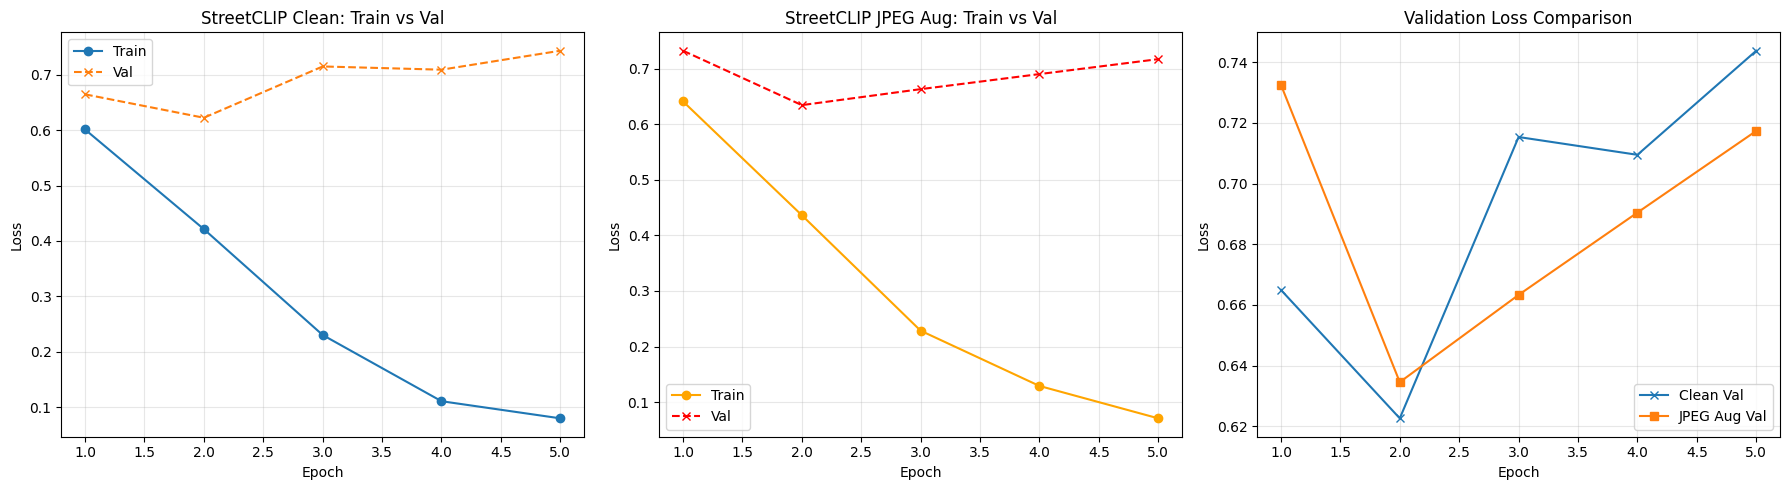

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Clean Model Plot
axes[0].plot(run_histories['streetclip_clean']['epoch'], run_histories['streetclip_clean']['train_loss'], marker='o', label='Train')
axes[0].plot(run_histories['streetclip_clean']['epoch'], run_histories['streetclip_clean']['val_loss'], marker='x', linestyle='--', label='Val')
axes[0].set_title('StreetCLIP Clean: Train vs Val')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. JPEG Augmented Model Plot
axes[1].plot(run_histories['streetclip_jpeg_aug']['epoch'], run_histories['streetclip_jpeg_aug']['train_loss'], marker='o', label='Train', color='orange')
axes[1].plot(run_histories['streetclip_jpeg_aug']['epoch'], run_histories['streetclip_jpeg_aug']['val_loss'], marker='x', linestyle='--', label='Val', color='red')
axes[1].set_title('StreetCLIP JPEG Aug: Train vs Val')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3. Validation Comparison
axes[2].plot(run_histories['streetclip_clean']['epoch'], run_histories['streetclip_clean']['val_loss'], marker='x', label='Clean Val')
axes[2].plot(run_histories['streetclip_jpeg_aug']['epoch'], run_histories['streetclip_jpeg_aug']['val_loss'], marker='s', label='JPEG Aug Val')
axes[2].set_title('Validation Loss Comparison')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Loss')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Saved outputs

Each run is saved to:
- `.../streetclip_clean/checkpoints/epoch_*`
- `.../streetclip_clean/best`
- `.../streetclip_clean/final`
- `.../streetclip_jpeg_aug/checkpoints/epoch_*`
- `.../streetclip_jpeg_aug/best`
- `.../streetclip_jpeg_aug/final`
